<>:59: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:59: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\ozhan\AppData\Local\Temp\ipykernel_18556\4045396857.py:59: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax3d.set_xlabel(r'Real ($\sigma$) - Stability'); ax3d.set_ylabel('Imaginary ($j\omega$) - Freq')


✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\49_laplace_2d.png


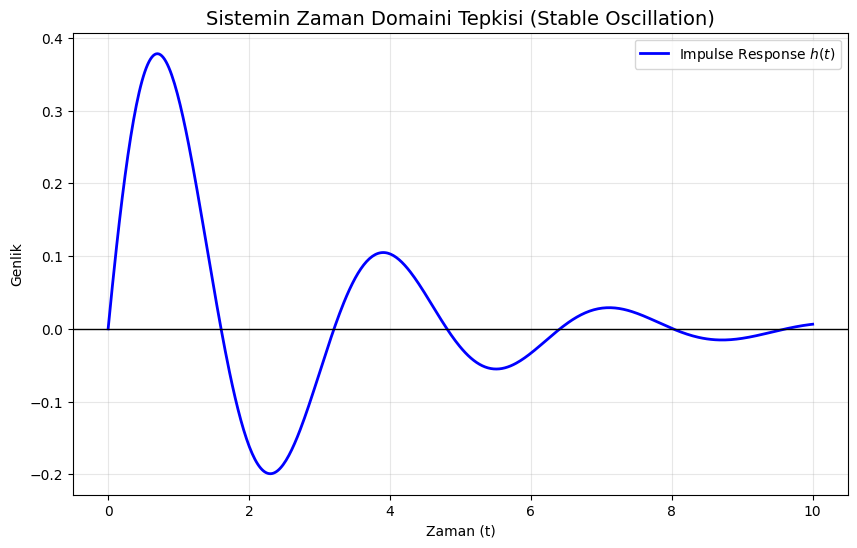

✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\49_laplace_3d.png


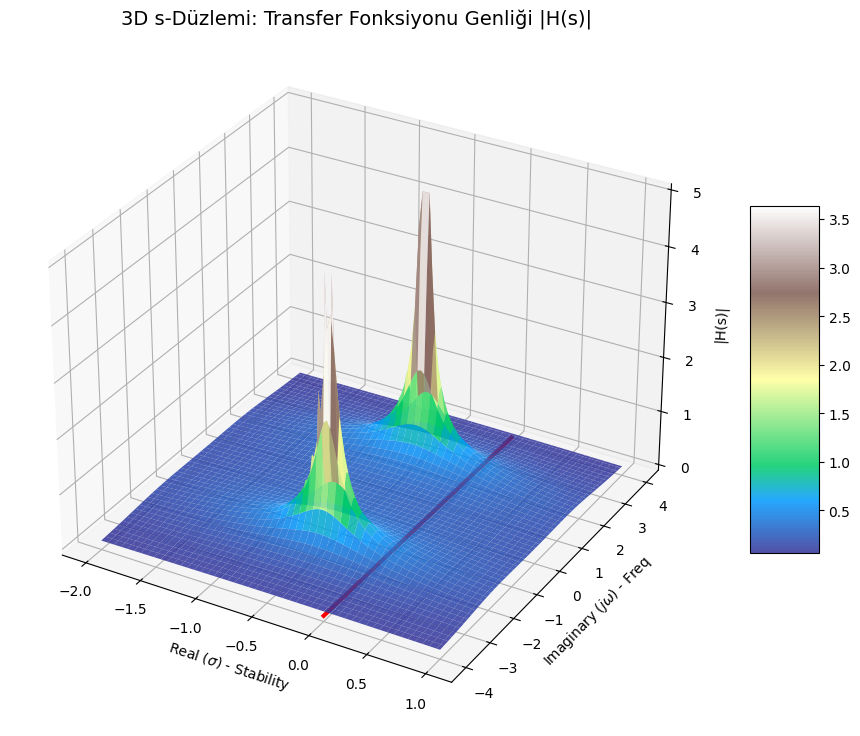

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_laplace_master():
    # --- 🎯 SENİN YOLUN (FIXED ASSET PATH) ---
    asset_path = r'C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Zaman Domaini: Impulse Response of a 2nd Order System
    # H(s) = 1 / (s^2 + 2zeta*wn*s + wn^2)
    t = np.linspace(0, 10, 500)
    zeta = 0.2  # Damping ratio (Underdamped)
    wn = 2.0    # Natural frequency
    
    # Zaman domaini karşılığı (Damped Sine)
    wd = wn * np.sqrt(1 - zeta**2)
    h_t = (1/wd) * np.exp(-zeta * wn * t) * np.sin(wd * t)

    # --- 📸 ASSET 1: TIME DOMAIN RESPONSE (49_laplace_2d.png) ---
    fig1 = plt.figure(figsize=(10, 6))
    plt.plot(t, h_t, 'b-', lw=2, label='Impulse Response $h(t)$')
    plt.axhline(0, color='black', lw=1)
    plt.title("Sistemin Zaman Domaini Tepkisi (Stable Oscillation)", fontsize=14)
    plt.xlabel("Zaman (t)"); plt.ylabel("Genlik")
    plt.grid(alpha=0.3); plt.legend()
    
    plt.savefig(os.path.join(asset_path, '49_laplace_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\49_laplace_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D POLE SURFACE (49_laplace_3d.png) ---
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    # s-plane grid (sigma and omega)
    sigma = np.linspace(-2, 1, 100)
    omega = np.linspace(-4, 4, 100)
    S_real, S_imag = np.meshgrid(sigma, omega)
    
    # H(s) = 1 / ((s - p1)(s - p2)) nerede p = -zeta*wn +/- j*wd
    p1 = complex(-zeta*wn, wd)
    p2 = complex(-zeta*wn, -wd)
    
    # Magnitude of Transfer Function |H(s)|
    # s = S_real + j*S_imag
    dist_p1 = np.sqrt((S_real - p1.real)**2 + (S_imag - p1.imag)**2)
    dist_p2 = np.sqrt((S_real - p2.real)**2 + (S_imag - p2.imag)**2)
    Z_mag = 1.0 / (dist_p1 * dist_p2)
    
    # Görselleştirme için piki sınırla (Sonsuza gitmesin)
    Z_mag = np.clip(Z_mag, 0, 5)

    surf = ax3d.plot_surface(S_real, S_imag, Z_mag, cmap='terrain', alpha=0.85, edgecolor='none')
    
    ax3d.set_title("3D s-Düzlemi: Transfer Fonksiyonu Genliği |H(s)|", fontsize=14)
    ax3d.set_xlabel(r'Real ($\sigma$) - Stability'); ax3d.set_ylabel('Imaginary ($j\omega$) - Freq')
    ax3d.set_zlabel('|H(s)|')
    
    # Kritik stabilite çizgisi (sigma = 0)
    ax3d.plot([0, 0], [-4, 4], [0, 0], color='red', lw=3, label='Stability Boundary')
    
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=5)
    plt.savefig(os.path.join(asset_path, '49_laplace_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\49_laplace_3d.png")
    plt.show()

if __name__ == "__main__":
    run_laplace_master()